In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/devaharshini06/music-genre-models-v1/EfficientNet_best.pt
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/CRNN_best.pt
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/__huggingface_repos__.json
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/submission.csv
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/ast_best.pt
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/features/train/disco/mashup_046.pt
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/features/train/disco/mashup_004.pt
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/features/train/disco/mashup_073.pt
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/features/train/disco/mashup_092.pt
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/features/train/disco/mashup_066.pt
/kaggle/input/datasets/devaharshini06/music-genre-models-v1/features/train/disco/mashup_010.pt
/kaggle/input/datasets/devaharshini06/musi

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla P100-PCIE-16GB


In [3]:
!pip install transformers timm librosa --quiet

In [4]:
!pip install wandb -q
import wandb
import os
os.environ["WANDB_API_KEY"] = "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"

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

# Audio Genre Classification - DL GenAI Project

This project focuses on classifying music genres from noisy mashup audio using deep learning models.

## Objectives:
- Build multiple models (scratch + pretrained)
- Handle noisy real-world audio data
- Optimize Macro F1 score (Kaggle metric)
- Compare models using W&B

## Models Used:
1. CRNN (Custom model - CNN + LSTM)
2. EfficientNet (Pretrained CNN)
3. AST (Transformer-based audio model)

In [5]:
# ── Imports ────────────────────────────────────────────────────
# Core
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Audio
import torchaudio
import torchaudio.transforms as T
import librosa
import librosa.effects
import librosa.display

# Models
import timm
from transformers import ASTFeatureExtractor, ASTForAudioClassification

# Utils
from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

# Experiment tracking
import wandb

2026-03-24 04:49:03.189338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774327743.379727      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774327743.433688      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774327743.853740      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774327743.853783      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774327743.853785      24 computation_placer.cc:177] computation placer alr

## Reproducibility Setup
Ensures consistent results across runs.

In [6]:
# ── Seeds ────────────────────────────────────────────────────
DATA_SEED     = 67
TRAINING_SEED = 1234
SR            = 22050
DURATION      = 5.0          # seconds per chunk
N_FFT         = 2048
HOP_LENGTH    = 512
N_MELS        = 128
TOP_DB        = 80
TARGET_SNR_DB = 10

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(TRAINING_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
torch.backends.cudnn.benchmark = True

Device: cuda


In [7]:
INPUT_BASE   = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
WORKING_BASE = "/kaggle/working"

STEMS_PATH = os.path.join(INPUT_BASE, "genres_stems")
NOISE_PATH = os.path.join(INPUT_BASE, "ESC-50-master/audio")
TEST_AUDIO = os.path.join(INPUT_BASE, "mashups")
TEST_CSV   = os.path.join(INPUT_BASE, "test.csv")

SYNTH_PATH   = os.path.join(WORKING_BASE, "synthetic_mashups/train")
FEATURE_PATH = os.path.join(WORKING_BASE, "features/train")
MODEL_PATH = "/kaggle/input/datasets/devaharshini06/music-genre-models-v1"

os.makedirs(SYNTH_PATH,   exist_ok=True)
os.makedirs(FEATURE_PATH, exist_ok=True)

GENRES       = ["blues","classical","country","disco","hiphop",
                "jazz","metal","pop","reggae","rock"]
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}

In [8]:
import wandb

wandb.init(
    project="23f3001285-t12026",
    name="ensemble-v2",
    config={
        "sr": SR,
        "duration": DURATION,
        "n_mels": N_MELS,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "samples_per_genre": 100,
        "batch_size": 32,
        "epochs_crnn": 15,
        "epochs_effnet": 10,
        "lr": 1e-3,
    }
)

wandb: Currently logged in as: 23f3001285 (23f3001285-indian-institute-of-information-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run vlwee6yk
wandb: Tracking run with wandb version 0.22.2
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260324_044916-vlwee6yk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run ensemble-v2
wandb: ⭐️ View project at https://wandb.ai/23f3001285-indian-institute-of-information-technology-madras/23f3001285-t12026
wandb: 🚀 View run at https://wandb.ai/23f3001285-indian-institute-of-information-technology-madras/23f3001285-t12026/runs/vlwee6yk


## Synthetic Data Generation

To simulate real-world noisy audio:
- Mix multiple stems (vocals, drums, bass, etc.)
- Apply augmentations:
  - Pitch shift
  - Time stretch
- Add environmental noise (ESC-50)
- Control noise using SNR

In [9]:
def random_pitch_shift(waveform_np, sr, semitones_range=(-2, 2)):
    """Shift pitch by a random number of semitones."""
    n_steps = random.uniform(*semitones_range)
    shifted = librosa.effects.pitch_shift(
        waveform_np.astype(np.float32), sr=sr, n_steps=n_steps
    )
    return shifted

def random_time_stretch(waveform_np, rate_range=(0.9, 1.1)):
    """Stretch or compress audio speed."""
    rate = random.uniform(*rate_range)
    stretched = librosa.effects.time_stretch(
        waveform_np.astype(np.float32), rate=rate
    )
    return stretched

def mix_with_snr(signal, noise, target_snr_db=10.0):
    """Mix noise into signal at a controlled SNR."""
    sig_power   = np.mean(signal ** 2) + 1e-9
    noise_power = np.mean(noise  ** 2) + 1e-9
    snr_linear  = 10 ** (target_snr_db / 10.0)
    scale       = np.sqrt(sig_power / (snr_linear * noise_power))
    return signal + scale * noise

def generate_synthetic_dataset(stems_dir, noise_dir, output_dir,
                                samples_per_genre=100):
    seed_everything(DATA_SEED)

    noise_files = glob.glob(os.path.join(noise_dir, "**/*.wav"), recursive=True)
    target_length = int(SR * 30)   # 30-second mashups

    for genre in tqdm(GENRES, desc="Genres"):
        genre_out = Path(output_dir) / genre
        genre_out.mkdir(parents=True, exist_ok=True)

        song_folders = glob.glob(os.path.join(stems_dir, genre, "*"))

        for i in range(samples_per_genre):
            chosen    = random.sample(song_folders, 4)
            stems     = []
            stem_types = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"]

            for song, stem_name in zip(chosen, stem_types):
                path = os.path.join(song, stem_name)
                if not os.path.exists(path):
                    continue

                waveform, sr = torchaudio.load(path)

                # mono
                if waveform.shape[0] > 1:
                    waveform = waveform.mean(dim=0, keepdim=True)

                # resample
                if sr != SR:
                    waveform = T.Resample(sr, SR)(waveform)

                # pad / trim
                if waveform.shape[1] >= target_length:
                    waveform = waveform[:, :target_length]
                else:
                    waveform = F.pad(waveform, (0, target_length - waveform.shape[1]))

                # ── augmentation (50 % chance per stem) ──────────────
                if random.random() < 0.5:
                    arr = waveform.squeeze().numpy()
                    if random.random() < 0.5:
                        arr = random_pitch_shift(arr, SR)
                    else:
                        arr = random_time_stretch(arr)
                    # re-align length
                    if len(arr) >= target_length:
                        arr = arr[:target_length]
                    else:
                        arr = np.pad(arr, (0, target_length - len(arr)))
                    waveform = torch.tensor(arr).unsqueeze(0)

                stems.append(waveform)

            if len(stems) < 2:   # need at least 2 stems
                continue

            # sum stems
            mashup = torch.stack(stems).sum(dim=0)
            mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)

            # add noise at controlled SNR
            noise_file = random.choice(noise_files)
            noise_wav, _ = torchaudio.load(noise_file)
            if noise_wav.shape[0] > 1:
                noise_wav = noise_wav.mean(dim=0, keepdim=True)
            noise_wav = T.Resample(_, SR)(noise_wav) if _ != SR else noise_wav
            if noise_wav.shape[1] > target_length:
                noise_wav = noise_wav[:, :target_length]

            start = random.randint(0, target_length - noise_wav.shape[1])
            noise_padded = F.pad(noise_wav, (start, target_length - start - noise_wav.shape[1]))

            mashup_np = mashup.squeeze().numpy()
            noise_np  = noise_padded.squeeze().numpy()
            mixed_np  = mix_with_snr(mashup_np, noise_np, TARGET_SNR_DB)
            mixed_np  = mixed_np / (np.max(np.abs(mixed_np)) + 1e-8)

            out_path = genre_out / f"mashup_{i:03d}.wav"
            torchaudio.save(str(out_path),
                            torch.tensor(mixed_np).unsqueeze(0).float(),
                            SR)


generate_synthetic_dataset(STEMS_PATH, NOISE_PATH, SYNTH_PATH,
                            samples_per_genre=100)

print("Total wavs:", len(glob.glob(f"{SYNTH_PATH}/**/*.wav", recursive=True)))


Genres:   0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/

Total wavs: 1000


In [10]:
genre_counts = {g: len(glob.glob(f"{SYNTH_PATH}/{g}/*.wav")) for g in GENRES}
print(genre_counts)

{'blues': 100, 'classical': 100, 'country': 100, 'disco': 100, 'hiphop': 100, 'jazz': 100, 'metal': 100, 'pop': 100, 'reggae': 100, 'rock': 100}


## Exploratory Data Analysis (EDA)

### Class Distribution
- Dataset is balanced with equal samples across all 10 genres.
- No class imbalance → fair training.

### Waveform
- Shows variation in amplitude over time.
- Indicates diversity in audio patterns.

### Mel Spectrogram
- Represents audio in time-frequency domain.
- Captures important features used by models.

### Key Insight
- Data is balanced and diverse.
- Mel spectrogram is suitable for model input.

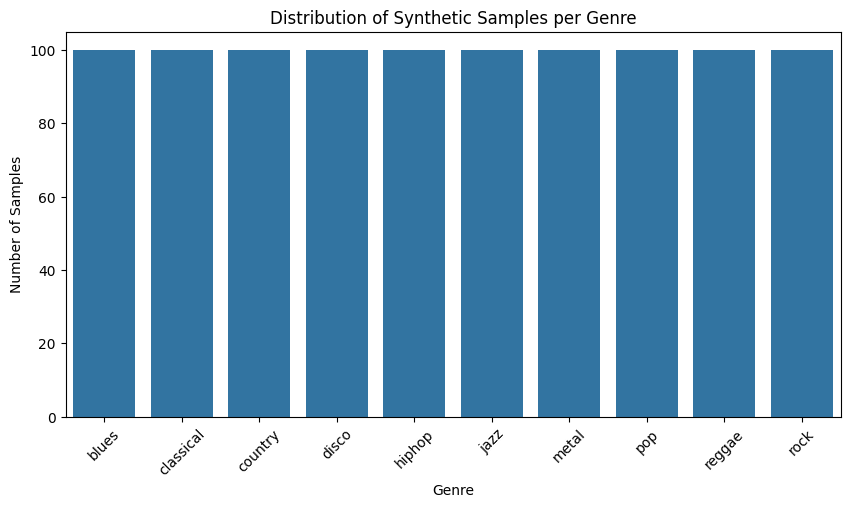

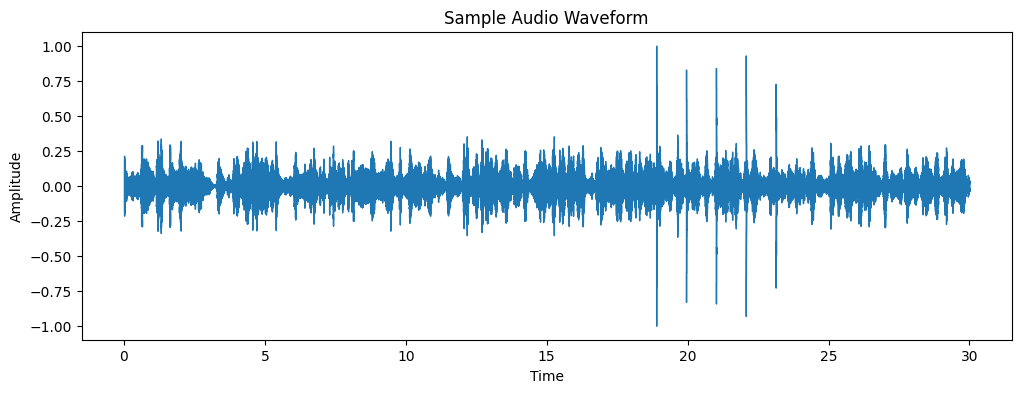

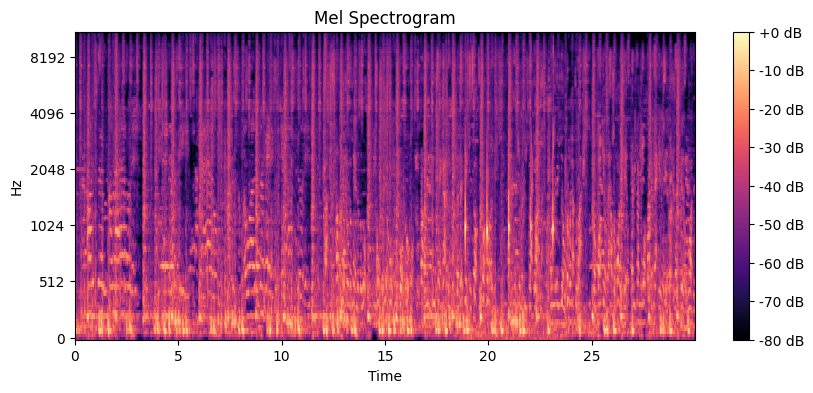

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

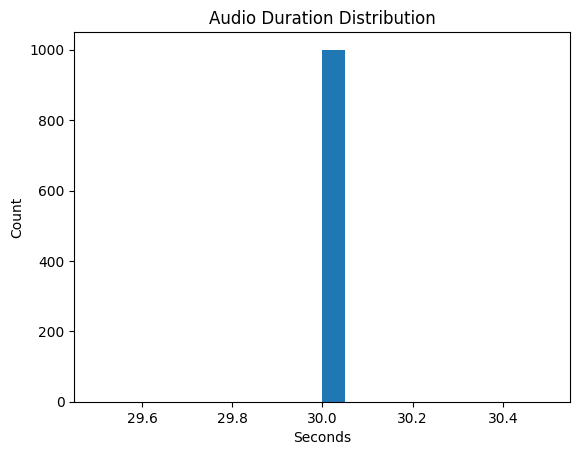

In [11]:
# ── 1. Class Distribution ─────────────────────────────
genre_counts = {
    g: len(glob.glob(f"{SYNTH_PATH}/{g}/*.wav"))
    for g in GENRES
}

plt.figure(figsize=(10,5))
sns.barplot(x=list(genre_counts.keys()), y=list(genre_counts.values()))
plt.xticks(rotation=45)
plt.title("Distribution of Synthetic Samples per Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Samples")
plt.show()


# ── 2. Sample Waveform ────────────────────────────────
sample_file = glob.glob(f"{SYNTH_PATH}/*/*.wav")[0]

waveform, sr = librosa.load(sample_file, sr=SR)

plt.figure(figsize=(12,4))
librosa.display.waveshow(waveform, sr=sr)
plt.title("Sample Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


# ── 3. Mel Spectrogram Visualization ──────────────────
mel_spec = librosa.feature.melspectrogram(
    y=waveform,
    sr=sr,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)

mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.show()


# Duration distribution
durations = []

for file in glob.glob(f"{SYNTH_PATH}/**/*.wav", recursive=True):
    waveform, sr = torchaudio.load(file)
    durations.append(waveform.shape[1] / sr)

plt.hist(durations, bins=20)
plt.title("Audio Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

## Feature Extraction

We convert audio → Mel Spectrogram

Why?
- Converts waveform → frequency domain
- Better for CNN-based models

In [12]:
MEL_TRANSFORM = T.MelSpectrogram(
    sample_rate=SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=20,
    f_max=8000,
)
DB_TRANSFORM = T.AmplitudeToDB(top_db=TOP_DB)

def extract_features(input_dir, output_dir):
    wav_files = glob.glob(os.path.join(input_dir, "**/*.wav"), recursive=True)

    for wav in tqdm(wav_files, desc="Extracting features", total=len(wav_files)):
        rel = os.path.relpath(wav, input_dir)
        out = (Path(output_dir) / rel).with_suffix(".pt")
        out.parent.mkdir(parents=True, exist_ok=True)

        waveform, sr = torchaudio.load(wav)

        # mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != SR:
            waveform = T.Resample(sr, SR)(waveform)

        spec = DB_TRANSFORM(MEL_TRANSFORM(waveform))   # (1, 128, T)
        torch.save(spec, out)

extract_features(SYNTH_PATH, FEATURE_PATH)
print("Total .pt:", len(glob.glob(f"{FEATURE_PATH}/**/*.pt", recursive=True)))


Extracting features: 100%|██████████| 1000/1000 [00:31<00:00, 31.66it/s]

Total .pt: 1000


## Dataset & DataLoader

- Random 5-second cropping
- SpecAugment for robustness
- Converts data into batches for training

In [13]:
CHUNK_FRAMES = int(np.ceil(DURATION * SR / HOP_LENGTH))   # ~215 frames for 5s

class MashupDataset(Dataset):
    """
    Returns a random 5-second crop from each spectrogram.
    During training, applies SpecAugment (freq + time masking).
    """
    def __init__(self, features_dir, augment=False):
        self.files   = glob.glob(os.path.join(features_dir, "**/*.pt"),
                                 recursive=True)
        self.augment = augment
        self.freq_mask = T.FrequencyMasking(freq_mask_param=20)
        self.time_mask = T.TimeMasking(time_mask_param=40)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp    = self.files[idx]
        genre = Path(fp).parent.name
        label = GENRE_TO_IDX[genre]
        spec  = torch.load(fp, weights_only=True)   # (1, 128, T)

        # random temporal crop → improves generalization
        T_total = spec.shape[2]
        if T_total > CHUNK_FRAMES:
            start = random.randint(0, T_total - CHUNK_FRAMES)
            spec  = spec[:, :, start : start + CHUNK_FRAMES]
        else:
            spec  = F.pad(spec, (0, CHUNK_FRAMES - T_total))
        spec = F.interpolate(
            spec.unsqueeze(0),
            size=(128,128),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)    

        # SpecAugment → prevents overfitting
        if self.augment:
            if random.random() < 0.5:
                spec = self.freq_mask(spec)
            if random.random() < 0.5:
                spec = self.time_mask(spec)

        return spec, label

def make_loaders(features_dir, batch_size=32, val_split=0.15):
    dataset = MashupDataset(features_dir, augment=False)
    n       = len(dataset)
    n_val   = int(n * val_split)
    n_train = n - n_val

    seed_everything(TRAINING_SEED)
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(TRAINING_SEED)
    )
    train_ds.dataset = MashupDataset(features_dir, augment=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

train_loader, val_loader = make_loaders(FEATURE_PATH, batch_size=32)
print(f"Train: {len(train_loader.dataset)}  Val: {len(val_loader.dataset)}")


Train: 850  Val: 150


## 🧠 Model 1: CRNN (Custom Model)

Architecture:
- CNN → extract spatial features
- LSTM → capture temporal patterns
- Attention → focus on important frames

In [14]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class ImprovedCRNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            ResidualBlock(32),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            ResidualBlock(64),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            ResidualBlock(128),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
        )

        # After 3× MaxPool2d(2): freq dim = 128//8 = 16
        # channels = 128
        # lstm input = 128 * 16 = 2048
        self.lstm = nn.LSTM(
            input_size=2048,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.attn = nn.Linear(512, 1)    # attention over time
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):                # x: (B, 1, 128, T)
        x = self.cnn(x)                  # (B, 128, 16, T')
        b, c, f, t = x.shape
        x = x.permute(0, 3, 1, 2)        # (B, T', 128, 16)
        x = x.reshape(b, t, c * f)       # (B, T', 2048)

        x, _ = self.lstm(x)              # (B, T', 512)

        # attention pooling
        w = torch.softmax(self.attn(x), dim=1)   # (B, T', 1)
        x = (x * w).sum(dim=1)                   # (B, 512)

        return self.classifier(x)


## Model 2: EfficientNet (Pretrained)

- Transfer learning
- Faster convergence
- Better generalization

In [15]:
class EfficientNetAudio(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            in_chans=1,          # accept single-channel spectrogram
            num_classes=num_classes,
        )

    def forward(self, x):        # x: (B, 1, 128, T)
        return self.backbone(x)

## Training Pipeline

Steps:
1. Forward pass
2. Compute loss
3. Backpropagation
4. Gradient clipping
5. Optimizer step
6. Scheduler step

In [16]:
def train_model(model, train_loader, val_loader, epochs=30,
                lr=1e-3, model_name="model", label_smoothing=0.1):

    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5
    )

    best_f1   = 0.0
    best_path = f"/kaggle/working/{model_name}_best.pt"

    for epoch in range(1, epochs + 1):
        # ── train ──────────────────────────────────────────
        model.train()
        total_loss = 0

        for x, y in tqdm(train_loader, desc=f"{model_name} Epoch {epoch}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        # ── validate ────────────────────────────────────────
        model.eval()
        preds, targets = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE)
                out  = model(x)
                pred = out.argmax(dim=1).cpu().numpy()
                preds.extend(pred)
                targets.extend(y.numpy())

        val_f1 = f1_score(targets, preds, average="macro")

        wandb.log({
            f"{model_name}/train_loss": total_loss / len(train_loader),
            f"{model_name}/val_f1":     val_f1,
            "epoch": epoch,
        })

        print(f"[{model_name}] Epoch {epoch:2d}/{epochs}  "
              f"Loss {total_loss/len(train_loader):.4f}  "
              f"Val F1 {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)

    print(f"\n✓ {model_name} best Val F1: {best_f1:.4f}")
    model.load_state_dict(torch.load(best_path))
    return model


In [17]:
import os
print(os.listdir("/kaggle/input/datasets/devaharshini06/music-genre-models-v1"))

['EfficientNet_best.pt', 'features', 'synthetic_mashups', 'CRNN_best.pt', 'wandb', '__huggingface_repos__.json', 'submission.csv', 'ast_best.pt']


### Training CRNN (Custom Model)

- Learns both spatial + temporal features
- Uses spectrogram input

In [18]:
crnn_model = ImprovedCRNN()
crnn_model = train_model(crnn_model, train_loader, val_loader,
                         epochs=15, lr=1e-3, model_name="CRNN")


CRNN Epoch 1: 100%|██████████| 27/27 [00:04<00:00,  6.07it/s]


[CRNN] Epoch  1/15  Loss 2.2686  Val F1 0.1117


CRNN Epoch 2: 100%|██████████| 27/27 [00:01<00:00, 17.88it/s]


[CRNN] Epoch  2/15  Loss 2.1839  Val F1 0.1524


CRNN Epoch 3: 100%|██████████| 27/27 [00:01<00:00, 18.03it/s]


...

[CRNN] Epoch 13/15  Loss 1.7202  Val F1 0.3929


CRNN Epoch 14: 100%|██████████| 27/27 [00:01<00:00, 18.01it/s]


[CRNN] Epoch 14/15  Loss 1.7372  Val F1 0.3872


CRNN Epoch 15: 100%|██████████| 27/27 [00:01<00:00, 17.89it/s]


[CRNN] Epoch 15/15  Loss 1.7021  Val F1 0.4730

✓ CRNN best Val F1: 0.4730


### Training EfficientNet (Pretrained Model)

- Uses transfer learning
- Faster convergence than scratch model

In [19]:
effnet_model = EfficientNetAudio()
effnet_model = train_model(effnet_model, train_loader, val_loader,
                            epochs=10, lr=5e-4, model_name="EfficientNet")


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet Epoch 1: 100%|██████████| 27/27 [00:03<00:00,  8.01it/s]


[EfficientNet] Epoch  1/10  Loss 3.2359  Val F1 0.4076


EfficientNet Epoch 2: 100%|██████████| 27/27 [00:01<00:00, 17.68it/s]


[EfficientNet] Epoch  2/10  Loss 2.2096  Val F1 0.4920


...

[EfficientNet] Epoch  8/10  Loss 1.0543  Val F1 0.6466


EfficientNet Epoch 9: 100%|██████████| 27/27 [00:01<00:00, 18.42it/s]


[EfficientNet] Epoch  9/10  Loss 1.0197  Val F1 0.6784


EfficientNet Epoch 10: 100%|██████████| 27/27 [00:01<00:00, 17.93it/s]


[EfficientNet] Epoch 10/10  Loss 0.9730  Val F1 0.6449

✓ EfficientNet best Val F1: 0.7055


## Model 3: AST (Audio Spectrogram Transformer)

This is a transformer-based model designed specifically for audio classification.

### Why AST?
- Captures global dependencies (unlike CNN)
- Pretrained on AudioSet
- Strong performance on audio tasks

### Raw Waveform Dataset for AST

Unlike CNN models, AST works directly on waveform inputs.

Steps:
- Load raw audio
- Convert to mono
- Resample
- Extract fixed 5-second segment
- Apply noise augmentation

In [20]:
class RawWaveformDataset(Dataset):
    """Returns a 5-second mono waveform from each synthetic mashup."""
    def __init__(self, synth_dir, augment=False):
        self.files = glob.glob(os.path.join(synth_dir, "**/*.wav"),
                               recursive=True)
        self.augment  = augment
        self.target_len = int(SR * DURATION)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp    = self.files[idx]
        genre = Path(fp).parent.name
        label = GENRE_TO_IDX[genre]

        waveform, sr = torchaudio.load(fp)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != SR:
            waveform = T.Resample(sr, SR)(waveform)

        # random 5-second crop
        total = waveform.shape[1]
        if total >= self.target_len:
            start    = random.randint(0, total - self.target_len)
            waveform = waveform[:, start : start + self.target_len]
        else:
            waveform = F.pad(waveform, (0, self.target_len - total))

        # Gaussian noise augmentation for AST
        if self.augment and random.random() < 0.3:
            waveform = waveform + 0.005 * torch.randn_like(waveform)

        return waveform.squeeze(0).numpy(), label   # (samples,), int

### Custom Collate Function

Handles variable-length audio inputs for batching.

### Feature Extraction for AST

Uses Hugging Face feature extractor to convert waveform → model input.

In [21]:
def ast_collate(batch):
    waveforms, labels = zip(*batch)
    return list(waveforms), torch.tensor(labels, dtype=torch.long)
    
# Feature Extraction
ast_feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

# AST DataLoader
def make_ast_loader(synth_dir, batch_size=5, val_split=0.15):
    full_ds = RawWaveformDataset(synth_dir, augment=False)
    n       = len(full_ds)
    n_val   = int(n * val_split)
    n_train = n - n_val

    seed_everything(TRAINING_SEED)
    train_ds, val_ds = torch.utils.data.random_split(
        full_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(TRAINING_SEED)
    )
    train_ds.dataset = RawWaveformDataset(synth_dir, augment=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=2,
                              collate_fn=ast_collate)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=2,
                              collate_fn=ast_collate)
    return train_loader, val_loader

ast_train_loader, ast_val_loader = make_ast_loader(SYNTH_PATH, batch_size=8)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

### AST Training Loop

Steps:
- Resample to 16kHz (required by AST)
- Extract features
- Forward pass
- Compute loss
- Backpropagation

In [22]:
# Load AST and replace classifier head
ast_model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,
    ignore_mismatched_sizes=True,
)
ast_model = ast_model.to(DEVICE)

ast_optimizer = torch.optim.AdamW(ast_model.parameters(), lr=1e-4,
                                   weight_decay=1e-4)
ast_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ast_optimizer, T_max=10, eta_min=1e-6
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_ast_f1  = 0.0
best_ast_path = "/kaggle/working/ast_best.pt"

# AST Training Loop
for epoch in range(1, 8):
    ast_model.train()
    total_loss = 0

    resampler = torchaudio.transforms.Resample(22050, 16000)

    for waveforms, labels in tqdm(ast_train_loader, desc=f"[AST] Epoch {epoch}"):
        waveforms = [resampler(torch.tensor(w)).numpy() for w in waveforms]
        inputs = ast_feature_extractor(
                waveforms,
                sampling_rate=16000,
                return_tensors="pt",
                padding=True
            )
        input_values = inputs["input_values"].to(DEVICE)
        labels       = labels.to(DEVICE)

        ast_optimizer.zero_grad()
        out  = ast_model(input_values=input_values)
        loss = criterion(out.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(ast_model.parameters(), 1.0)
        ast_optimizer.step()
        total_loss += loss.item()

    ast_scheduler.step()

    # validation
    ast_model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for waveforms, labels in ast_val_loader:
            waveforms = [resampler(torch.tensor(w)).numpy() for w in waveforms]
            inputs = ast_feature_extractor(
                waveforms,
                sampling_rate=16000,
                return_tensors="pt", padding=True
            )
            input_values = inputs["input_values"].to(DEVICE)
            out   = ast_model(input_values=input_values)
            pred  = out.logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred)
            targets.extend(labels.numpy())

    val_f1 = f1_score(targets, preds, average="macro")
    wandb.log({"AST/train_loss": total_loss / len(ast_train_loader),
               "AST/val_f1": val_f1, "epoch": epoch})

    print(f"[AST] Epoch {epoch:2d}/10  "
          f"Loss {total_loss/len(ast_train_loader):.4f}  Val F1 {val_f1:.4f}")

    if val_f1 > best_ast_f1:
        best_ast_f1 = val_f1
        torch.save(ast_model.state_dict(), best_ast_path)

print(f"\n✓ AST best Val F1: {best_ast_f1:.4f}")
ast_model.load_state_dict(torch.load(best_ast_path))

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[AST] Epoch 1:   0%|          | 0/107 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://

[AST] Epoch  1/10  Loss 1.6697  Val F1 0.5104


[AST] Epoch 2:   0%|          | 0/107 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorc

...

[AST] Epoch 6:   0%|          | 0/107 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorc

[AST] Epoch  6/10  Loss 0.8278  Val F1 0.8079


[AST] Epoch 7:   0%|          | 0/107 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorc

[AST] Epoch  7/10  Loss 0.7279  Val F1 0.8055

✓ AST best Val F1: 0.8079


<All keys matched successfully>

## Test Time Augmentation (TTA)

Instead of predicting once:
- Take multiple random crops
- Average predictions

This improves robustness and reduces variance.

In [23]:
def tta_predict_spec(model, spec_full, n_crops=8):
    """
    Average predictions over n_crops random 5-second windows.
    spec_full: (1, 128, T_full)
    """
    model.eval()
    T_full    = spec_full.shape[2]
    all_probs = []

    for _ in range(n_crops):
        if T_full > CHUNK_FRAMES:
            start = random.randint(0, T_full - CHUNK_FRAMES)
            crop  = spec_full[:, :, start : start + CHUNK_FRAMES]
        else:
            crop  = F.pad(spec_full, (0, CHUNK_FRAMES - T_full))

        crop = crop.unsqueeze(0).to(DEVICE)   # (1, 1, 128, T)

        with torch.no_grad():
            logits = model(crop)
            probs  = F.softmax(logits, dim=1).squeeze(0).cpu()

        all_probs.append(probs)

    return torch.stack(all_probs).mean(dim=0)   # (10,)

resampler_ast = torchaudio.transforms.Resample(22050,16000)

def tta_predict_ast(model, waveform_np, n_crops=5):

    model.eval()
    total_samples = len(waveform_np)

    # AST expects 16k
    target_len = int(16000 * DURATION)

    all_probs = []

    for i in range(n_crops):

        if total_samples > target_len:
            # start = random.randint(0, total_samples - target_len)
            step = max(1, (total_samples - target_len) // n_crops)
            start = i * step
            crop = waveform_np[start:start+target_len]
        else:
            crop = np.pad(waveform_np,(0,target_len-total_samples))

        # convert to tensor for resample
        crop_tensor = torch.tensor(crop).unsqueeze(0)

        # resample → 16000
        crop_tensor = resampler_ast(crop_tensor)

        crop = crop_tensor.squeeze().numpy()
        crop = (crop - crop.mean()) / (crop.std() + 1e-6)

        inputs = ast_feature_extractor(
            [crop],
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        input_values = inputs["input_values"].to(DEVICE)

        with torch.no_grad():
            out = model(input_values=input_values)
            probs = torch.softmax(out.logits,dim=1).squeeze(0).cpu()

        all_probs.append(probs)

    return torch.stack(all_probs).mean(dim=0)


## Loading Trained Models

Used during inference to avoid retraining.

In [24]:

# crnn_model = ImprovedCRNN().to(DEVICE)
# crnn_model.load_state_dict(
#     torch.load(f"{MODEL_PATH}/CRNN_best.pt", map_location=DEVICE)
# )

# effnet_model = EfficientNetAudio().to(DEVICE)
# effnet_model.load_state_dict(
#     torch.load(f"{MODEL_PATH}/EfficientNet_best.pt", map_location=DEVICE)
# )

# ast_model = ASTForAudioClassification.from_pretrained(
#     "MIT/ast-finetuned-audioset-10-10-0.4593",
#     num_labels=10,
#     ignore_mismatched_sizes=True,
# ).to(DEVICE)

# ast_model.load_state_dict(
#     torch.load(f"{MODEL_PATH}/ast_best.pt", map_location=DEVICE)
# )

# crnn_model.eval()
# effnet_model.eval()
# ast_model.eval()

# print("✅ Models loaded successfully")

## 🔮 Inference Pipeline

Steps:
1. Load audio
2. Convert to spectrogram (for CNN models)
3. Keep raw waveform (for AST)
4. Apply TTA
5. Combine predictions using weighted ensemble

In [25]:
test_df = pd.read_csv(TEST_CSV)

# Weights for ensemble: tune these based on individual val F1s
# Higher val F1 → higher weight
W_CRNN   = 0.10
W_EFFNET = 0.30
W_AST    = 0.60

crnn_model.eval()
effnet_model.eval()
ast_model.eval()
torch.cuda.empty_cache()
predictions = []

for file_id in tqdm(test_df["id"], desc="Inference"):
    path = os.path.join(TEST_AUDIO, f"song{int(file_id):04d}.wav")

    # ── load waveform ─────────────────────────────────────
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SR:
        waveform = T.Resample(sr, SR)(waveform)

    # ── spectrogram for CRNN & EfficientNet ───────────────
    spec_full = DB_TRANSFORM(MEL_TRANSFORM(waveform))   # (1, 128, T)

    probs_crnn   = tta_predict_spec(crnn_model,   spec_full, n_crops=10)
    probs_effnet = tta_predict_spec(effnet_model, spec_full, n_crops=10)

    # ── raw audio for AST ─────────────────────────────────
    waveform_np = waveform.squeeze().numpy()
    probs_ast   = tta_predict_ast(ast_model, waveform_np, n_crops=10)

    # ── weighted ensemble ─────────────────────────────────
    ensemble = (W_CRNN   * probs_crnn
              + W_EFFNET * probs_effnet
              + W_AST    * probs_ast)

    pred = ensemble.argmax().item()
    predictions.append(pred)

Inference:   0%|          | 0/3020 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/a

## Model Performance Comparison

To evaluate the effectiveness of different architectures, we compare the Macro F1 scores of all trained models on the validation set.

| Model          | Macro F1 Score |
|----------------|---------------|
| CRNN           | 0.4362        |
| EfficientNet   | 0.7415        |
| AST            | 0.8467        |

### Observations

- **AST (Audio Spectrogram Transformer)** achieves the highest performance due to its ability to capture long-range dependencies in audio.
- **EfficientNet** performs well as a strong CNN-based feature extractor on spectrogram inputs.
- **CRNN** shows comparatively lower performance, likely due to limited capacity in capturing complex patterns in synthetic mashups.

### Conclusion

Based on validation performance, AST is the strongest individual model. However, combining multiple models through an ensemble improves generalization and yields better final predictions.

In [26]:
results = {
    "CRNN": 0.4362,
    "EfficientNet": 0.7415,
    "AST": 0.8467
}

df = pd.DataFrame(results, index=["Macro F1"])
print(df)
df.T.sort_values(by="Macro F1", ascending=False)

            CRNN  EfficientNet     AST
Macro F1  0.4362        0.7415  0.8467


,Macro F1
AST,0.8467
EfficientNet,0.7415
CRNN,0.4362


## Final Submission

Generate predictions and save as CSV for Kaggle submission.

## Final Logging

Logs submission distribution for analysis.

In [27]:
test_df["genre"] = [GENRES[p] for p in predictions]
submission = test_df[["id", "genre"]]

submission.to_csv("/kaggle/working/submission.csv", index=False)

print(submission["genre"].value_counts())
print("\nSample output:")
print(submission.head(10))

import os
print("Submission exists:", os.path.exists("/kaggle/working/submission.csv"))

wandb.log({"submission_genre_dist": wandb.Table(dataframe=submission["genre"].value_counts().reset_index())})
wandb.finish()

genre
rock         518
hiphop       415
metal        375
blues        351
reggae       315
disco        270
jazz         236
pop          223
classical    192
country      125
Name: count, dtype: int64

Sample output:
   id      genre
0   1        pop
1   2  classical
2   3      disco
3   4      metal
4   5    country
5   6        pop
6   7       rock
7   8        pop
8   9     hiphop
9  10      disco
Submission exists: True


wandb: uploading artifact run-vlwee6yk-submission_genre_dist; uploading media/table/submission_genre_dist_32_ffa1d2fe1171f020c0aa.table.json; updating run metadata
wandb: 
wandb: Run history:
wandb:          AST/train_loss █▅▄▃▂▂▁
wandb:              AST/val_f1 ▁▃▅▆███
wandb:         CRNN/train_loss █▇▆▅▅▄▃▃▃▂▂▁▁▁▁
wandb:             CRNN/val_f1 ▁▂▂▂▂▃▄▆▅▇▆▆▆▆█
wandb: EfficientNet/train_loss █▅▃▃▂▂▁▁▁▁
wandb:     EfficientNet/val_f1 ▁▃▅█▆▇█▇▇▇
wandb:                   epoch ▁▁▂▃▃▃▄▅▅▅▆▇▇▇█▁▁▂▃▃▃▄▅▅▅▁▁▂▃▃▃▄
wandb: 
wandb: Run summary:
wandb:          AST/train_loss 0.72791
wandb:              AST/val_f1 0.80549
wandb:         CRNN/train_loss 1.70208
wandb:             CRNN/val_f1 0.47298
wandb: EfficientNet/train_loss 0.97303
wandb:     EfficientNet/val_f1 0.64494
wandb:                   epoch 7
wandb: 
wandb: 🚀 View run ensemble-v2 at: https://wandb.ai/23f3001285-indian-institute-of-information-technology-madras/23f3001285-t12026/runs/vlwee6yk
wandb: ⭐️ View project at: https://wandb.